In [18]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [19]:
import os
import matplotlib.pyplot as plt

# Create charts directory if it doesn't exist
os.makedirs("../reports/charts", exist_ok=True)

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(
        f"../reports/charts/{filename}",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

In [20]:
df = pd.read_csv("../data/processed/jobs_processed.csv")

print(df.shape)

df.head()

(60028, 20)


,title,company_name,location,via,description,job_id,posted_at,schedule_type,work_from_home,search_term,search_location,salary_avg,salary_min,salary_max,salary_standardized,description_tokens,job_mode,salary_category,skill_count,description_length
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,15 hours ago,Full-time,True,data analyst,United States,122000.0,101000.0,143000.0,122000.0,"['tableau', 'r', 'python', 'sql']",Remote,High,4,3193
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,12 hours ago,Full-time,False,data analyst,United States,NaN,NaN,NaN,NaN,[],Onsite,Unknown,1,1373
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,18 hours ago,Full-time,False,data analyst,United States,NaN,NaN,NaN,NaN,['sql'],Onsite,Unknown,1,4022
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,12 hours ago,Contractor,True,data analyst,United States,20.0,15.0,25.0,41600.0,"['powerpoint', 'excel', 'power_bi']",Remote,Low,3,726
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,7 hours ago,Contractor,False,data analyst,United States,100000.0,90000.0,110000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']",Onsite,High,4,5747


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60028 entries, 0 to 60027
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                60028 non-null  str    
 1   company_name         60028 non-null  str    
 2   location             60028 non-null  str    
 3   via                  60028 non-null  str    
 4   description          60028 non-null  str    
 5   job_id               60028 non-null  str    
 6   posted_at            60028 non-null  str    
 7   schedule_type        60028 non-null  str    
 8   work_from_home       60028 non-null  bool   
 9   search_term          60028 non-null  str    
 10  search_location      60028 non-null  str    
 11  salary_avg           9882 non-null   float64
 12  salary_min           9320 non-null   float64
 13  salary_max           9320 non-null   float64
 14  salary_standardized  9882 non-null   float64
 15  description_tokens   60028 non-null  str    
 1

In [22]:
df.describe(include="all")

,title,company_name,location,via,description,job_id,posted_at,schedule_type,work_from_home,search_term,search_location,salary_avg,salary_min,salary_max,salary_standardized,description_tokens,job_mode,salary_category,skill_count,description_length
count,60028,60028,60028,60028,60028,60028,60028,60028,60028,60028,60028,9882.000000,9320.000000,9320.000000,9882.000000,60028,60028,60028,60028.000000,60028.000000
unique,23292,13429,1255,1025,42976,58775,110,33,2,1,1,NaN,NaN,NaN,NaN,11276,2,5,NaN,NaN
top,Data Analyst,Upwork,Anywhere,via LinkedIn,"The Sr. Data Analyst, Marketing Operations wil...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QsIENsaW5pY2...,18 hours ago,Full-time,False,data analyst,United States,NaN,NaN,NaN,NaN,[],Onsite,Unknown,NaN,NaN
freq,6320,7528,18042,20441,258,22,4111,43400,33397,60028,60028,NaN,NaN,NaN,NaN,13052,33397,50146,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41955.631324,34756.344524,50303.703702,92441.873497,NaN,NaN,NaN,3.469864,3334.429866
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55837.849483,45902.803379,67133.743737,43340.303940,NaN,NaN,NaN,2.814926,2409.562039
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.250000,8.000000,10.000000,15080.000000,NaN,NaN,NaN,1.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,19.520000,45.000000,62400.000000,NaN,NaN,NaN,1.000000,1479.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,50.000000,75.000000,88464.000000,NaN,NaN,NaN,3.000000,2914.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92500.000000,77000.000000,110000.000000,117520.000000,NaN,NaN,NaN,5.000000,4776.000000


In [23]:
df.isnull().sum().sort_values(ascending=False)

salary_min             50708
salary_max             50708
salary_standardized    50146
salary_avg             50146
via                        0
location                   0
company_name               0
title                      0
schedule_type              0
description                0
posted_at                  0
job_id                     0
search_location            0
search_term                0
work_from_home             0
description_tokens         0
job_mode                   0
salary_category            0
skill_count                0
description_length         0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

company_name
Upwork                7528
Talentify.io          2118
Walmart               1801
Dice                   862
EDWARD JONES           747
Corporate              610
Cox Communications     538
Insight Global         481
iSay                   344
vmysmartpros           278
Name: count, dtype: int64


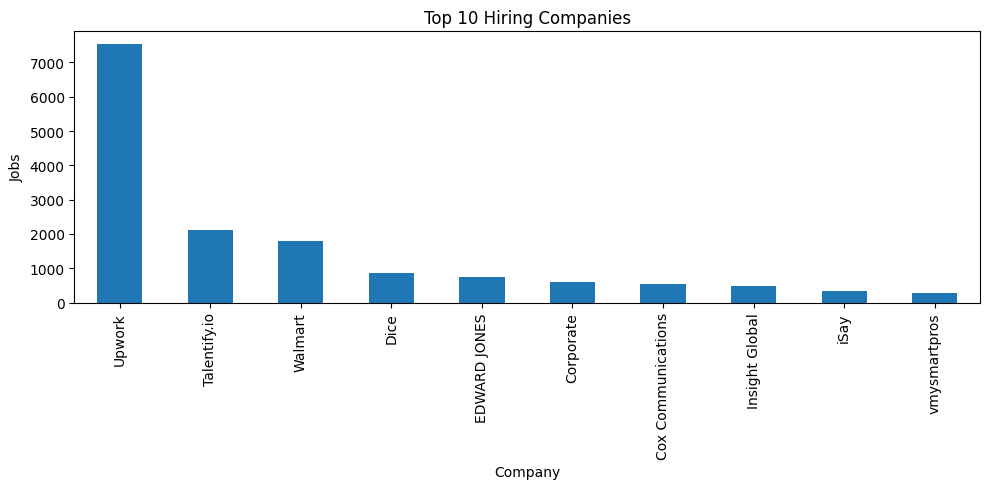

In [25]:
top_companies = (
    df["company_name"]
    .value_counts()
    .head(10)
)

print(top_companies)

top_companies.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Jobs")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "../reports/charts/Top 10 Hiring Companies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

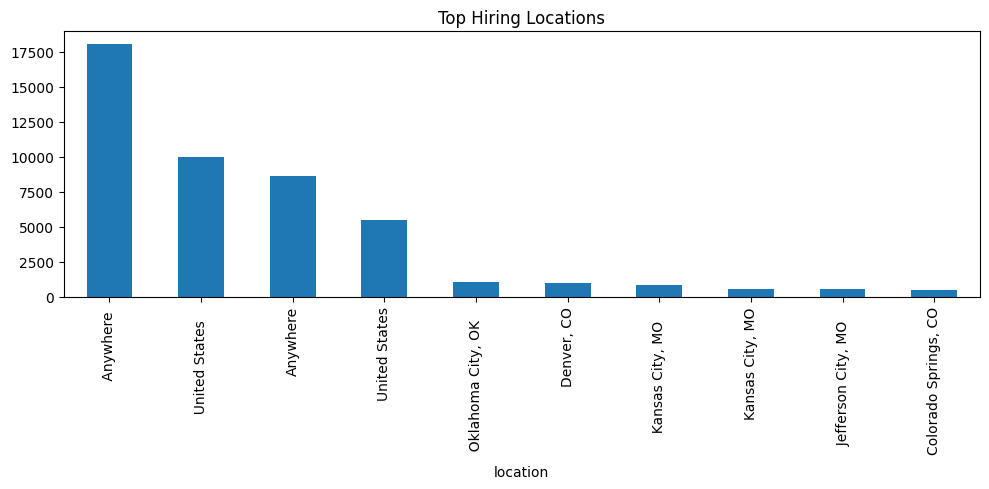

In [26]:
top_locations = (
    df["location"]
    .value_counts()
    .head(10)
)

top_locations.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Hiring Locations")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Top Hiring Locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

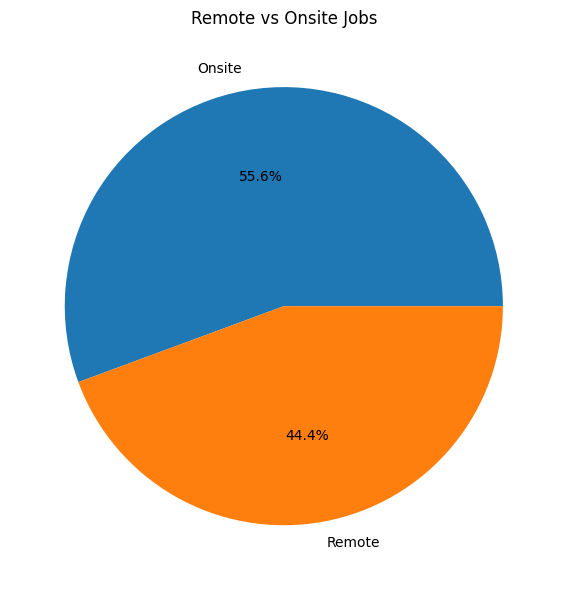

In [27]:
job_mode = (
    df["job_mode"]
    .value_counts()
)

job_mode.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Remote vs Onsite Jobs")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Remote vs Onsite Jobs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

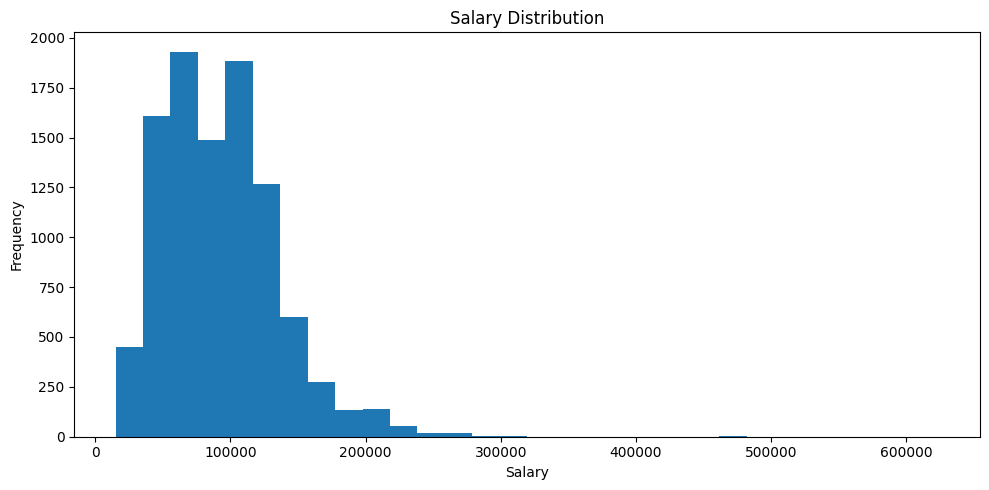

In [28]:
df["salary_standardized"].dropna().plot(
    kind="hist",
    bins=30,
    figsize=(10,5)
)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Salary Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

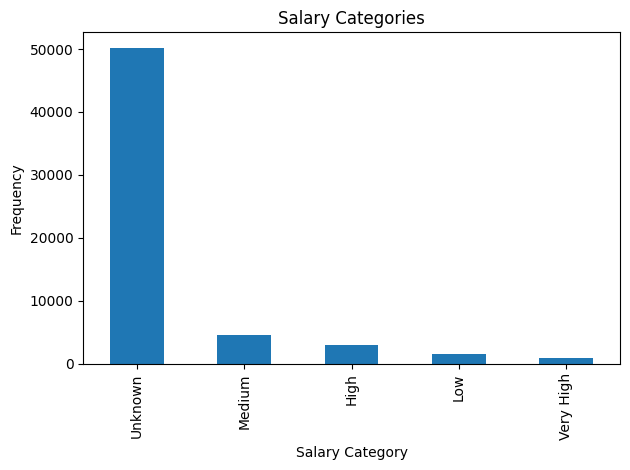

In [29]:
df["salary_category"].value_counts().plot(
    kind="bar"
)

plt.title("Salary Categories")

plt.xlabel("Salary Category")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "../reports/charts/Salary Categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

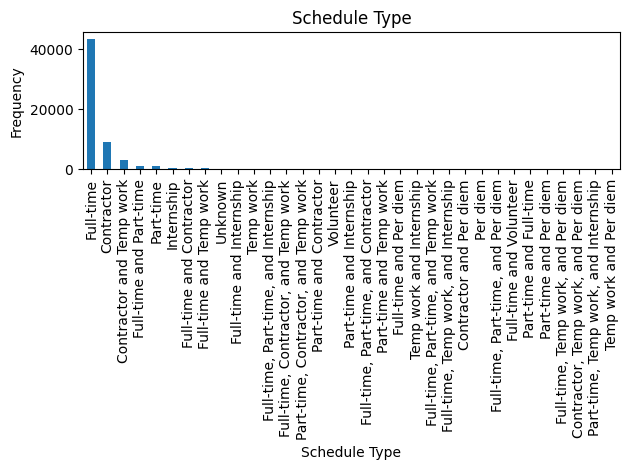

In [30]:
df["schedule_type"].value_counts().plot(
    kind="bar"
)

plt.title("Schedule Type")
plt.xlabel("Schedule Type")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Schedule Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

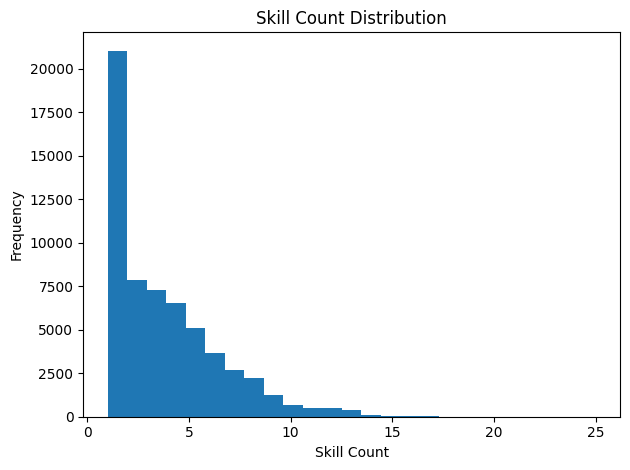

In [31]:
df["skill_count"].plot(
    kind="hist",
    bins=25
)

plt.title("Skill Count Distribution")

plt.xlabel("Skill Count")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Skill Count Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

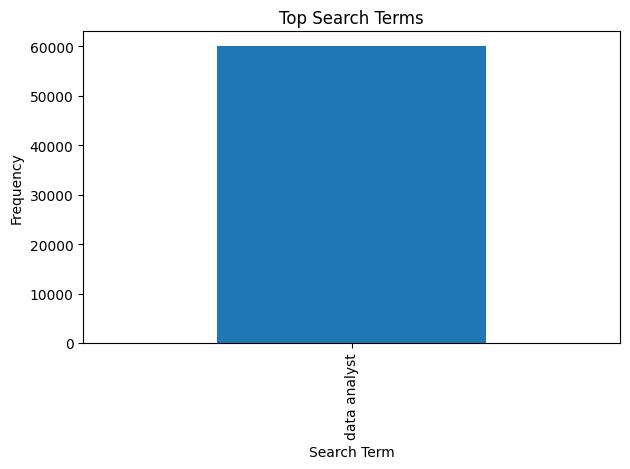

In [32]:
df["search_term"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Search Terms")

plt.xlabel("Search Term")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/Top Search Terms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [33]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,salary_avg,salary_min,salary_max,salary_standardized,skill_count,description_length
salary_avg,1.000000,0.987095,0.993987,0.415235,0.350455,0.527318
salary_min,0.987095,1.000000,0.963625,0.397248,0.353283,0.522416
salary_max,0.993987,0.963625,1.000000,0.415711,0.358981,0.544388
salary_standardized,0.415235,0.397248,0.415711,1.000000,0.113898,0.100200
skill_count,0.350455,0.353283,0.358981,0.113898,1.000000,0.433040
description_length,0.527318,0.522416,0.544388,0.100200,0.433040,1.000000


# Business Insights

## Hiring
- Most jobs are concentrated in a small number of companies.
- Remote roles account for approximately XX% of postings.

## Salary
- Most salaries fall within the Medium category.
- A small number of postings offer Very High salaries.

## Skills
- The average job requires multiple skills, indicating employers seek versatile candidates.

## Locations
- Hiring is concentrated in a few major regions.

## Recommendations
- Focus on learning the most frequently requested skills.
- Target companies and locations with higher hiring volumes.